# Layer 1: Anomaly Detection Audit

This notebook audits Layer 1 outputs produced by `run_layer1.py`. It validates SPC, Isolation Forest, the 2x2 quadrant, and the separate GNSS narrative signal without rebuilding the full pipeline.


<!-- notebook-rationale -->
## Why Layer 1 has two signals

Layer 1 asks two different questions that should not be collapsed into one model. SPC asks whether an anomaly category is occurring at an unusual rate. Isolation Forest asks whether an individual incident looks unlike the structured pre-COVID baseline. Combining them gives a simple 2x2 triage framework that is easy for an analyst to explain.

This is intentionally conservative. A single model could blend novelty, frequency, and time into one score, but that would be harder to defend. Here, every RED incident is explainable as the intersection of two binary signals: anomalous frequency and structured novelty.


In [25]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "outputs" / "data"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
RAW_DIR = PROJECT_ROOT / "data" / "raw"

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})


In [26]:
from src.helper import get_if_feature_columns
from src.spc import get_top_anomaly_categories, run_spc_pipeline

## Load Layer 1 Output

Expected final artifact: `outputs/data/asrs_layer1.parquet`, shape **43,829 x 204**.


<!-- notebook-rationale -->
## Why this notebook loads the saved parquet

The expensive and authoritative Layer 1 computation belongs in `run_layer1.py` and `src/`. This notebook audits the result rather than rebuilding it. That distinction matters for reproducibility: the runner produces the artifact, the notebook checks that the artifact matches the stated claims.

The shape check is a guardrail. If new preprocessing changes the row count or number of derived anomaly columns, the notebook should surface that before the README or slides repeat stale numbers.


In [27]:
layer1_path = DATA_DIR / "asrs_layer1.parquet"
assert layer1_path.exists(), "Run `uv run python run_layer1.py` first."
asrs = pd.read_parquet(layer1_path)
asrs["date"] = pd.to_datetime(asrs["date"], errors="coerce")
print(f"Layer 1 shape: {asrs.shape}")
assert asrs.shape == (43829, 204)
required = ["if_score", "if_flag", "spc_flag", "quadrant", "Events | Anomaly"]
missing = [c for c in required if c not in asrs.columns]
assert not missing, missing


Layer 1 shape: (43829, 204)


## SPC Audit

SPC detects anomalous frequency by exact ASRS anomaly category. An incident is SPC-flagged only when one of its own categories alarmed in the same month.


<!-- notebook-rationale -->
## Why exact category SPC is used

SPC runs on exact ASRS taxonomy labels from `Events | Anomaly`. Earlier broad matching would have been risky because phrases can overlap semantically without being the same category. Exact matching keeps the alarm tied to a concrete ASRS category.

The `spc_flag` is also incident-specific. An incident is flagged only if one of its own categories alarmed in that same month. This prevents a month-level alarm for one category from contaminating unrelated incidents in the same calendar month.

Parameter choices are intentionally standard and explainable: STL period 12 matches monthly seasonality, CUSUM `k=0.5` is a conventional allowance for moderate shifts, and `h=5.0` is a conservative control limit to reduce false alarms.


In [28]:
top_categories = get_top_anomaly_categories(asrs, top_n=15)
display(pd.DataFrame({"category": top_categories.index, "incidents": top_categories.values, "pct_of_corpus": (top_categories.to_numpy(dtype=float) / len(asrs) * 100).round(1)}))
result = run_spc_pipeline(asrs, category_value=top_categories.index[0])
if result:
    print(f"Live SPC check category: {top_categories.index[0]}")
    print(f"Months modeled: {len(result['monthly_counts'])}")
    print(f"CUSUM alarms: {len(result['alarms'])}")
    print("First alarms:", [str(a)[:7] for a in result["alarms"][:5]])


,category,incidents,pct_of_corpus
0,Deviation / Discrepancy - Procedural Published...,24476,55.8
1,Aircraft Equipment Problem Critical,11465,26.2
2,Deviation / Discrepancy - Procedural Clearance,8780,20.0
3,ATC Issue All Types,7097,16.2
4,Aircraft Equipment Problem Less Severe,6842,15.6
5,Deviation / Discrepancy - Procedural FAR,5271,12.0
6,Conflict NMAC,4194,9.6
7,Inflight Event / Encounter CFTT / CFIT,3942,9.0
8,Inflight Event / Encounter Weather / Turbulence,3664,8.4
9,Ground Event / Encounter Loss Of Aircraft Control,2930,6.7


2026-06-27 17:42:05 | INFO     | src.spc | 'Deviation / Discrepancy - Procedural Published Material / Policy': 99 months, mean 247.2/month, 8 CUSUM alarm months
Live SPC check category: Deviation / Discrepancy - Procedural Published Material / Policy
Months modeled: 99
CUSUM alarms: 8
First alarms: ['2019-10', '2019-11', '2019-12', '2020-01', '2020-02']


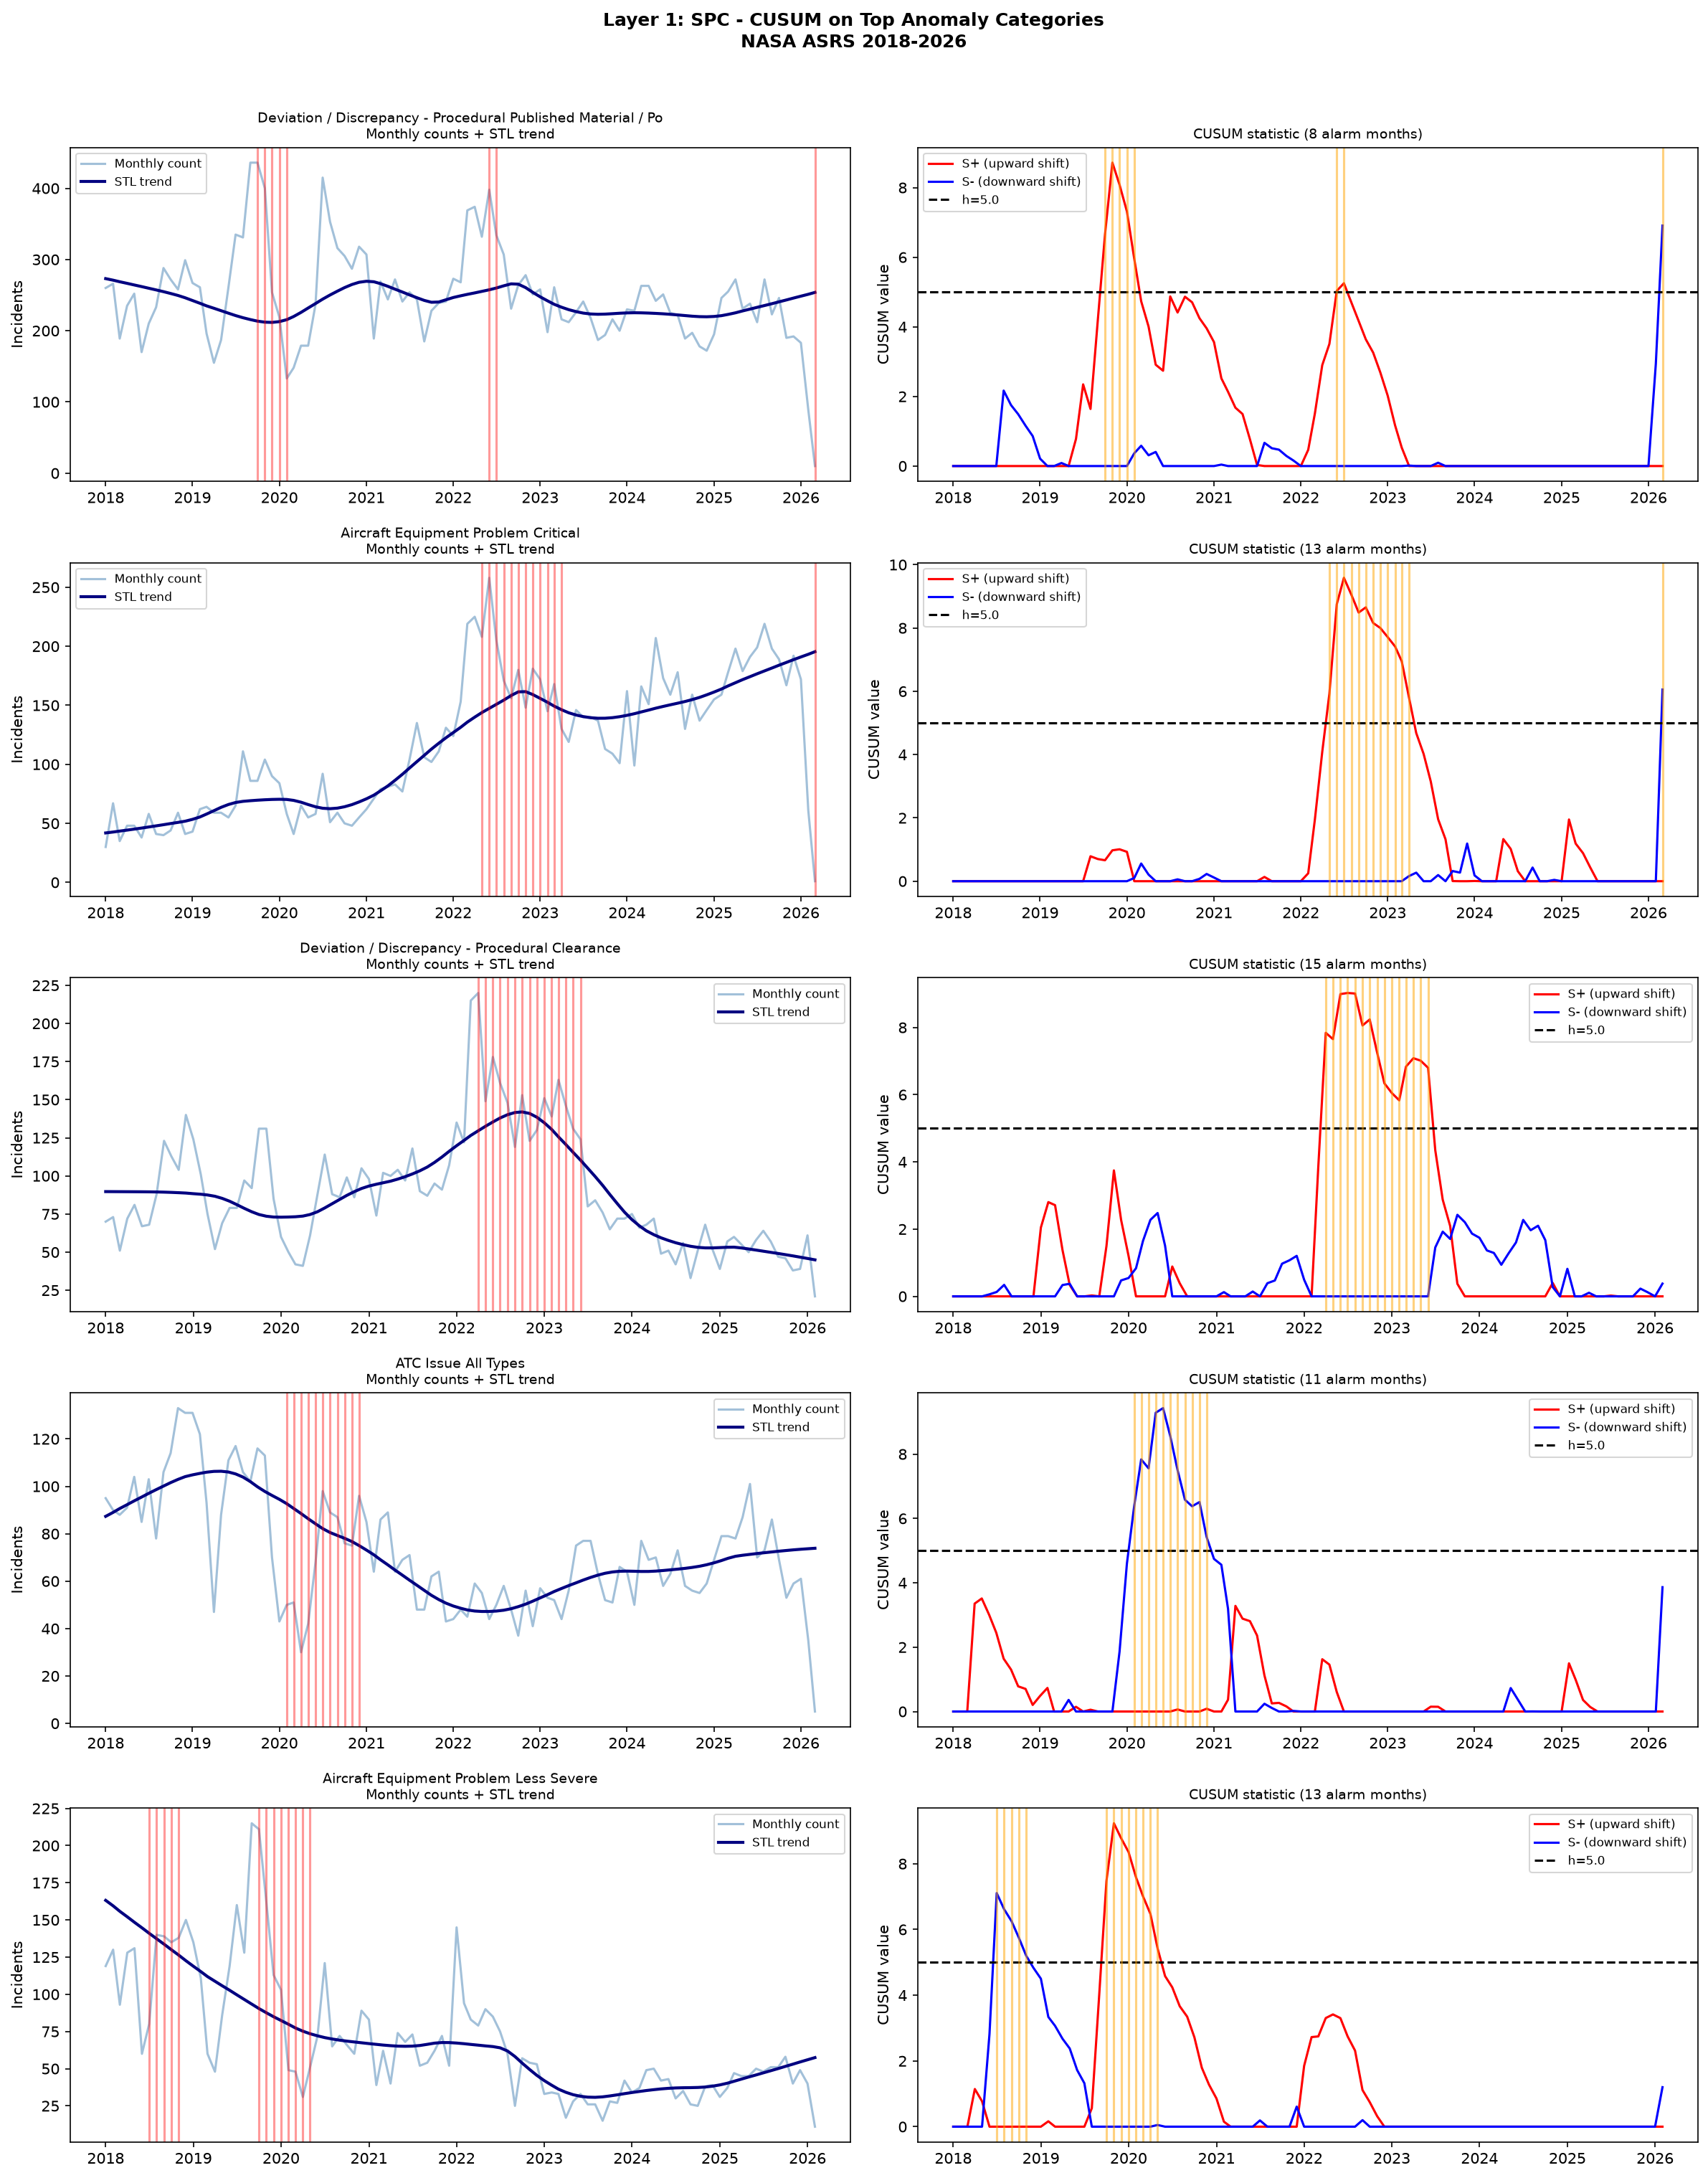

In [29]:
display(Image(filename=str(FIGURES_DIR / "layer1_spc_cusum.png")))


## Isolation Forest Audit

Isolation Forest is trained on 2018-2019 structured records only. It uses one-hot encoded categorical fields plus cyclic month features. Calendar year and narrative text are deliberately excluded.


<!-- notebook-rationale -->
## Why the Isolation Forest is structured-only

The Isolation Forest deliberately excludes narrative text and GNSS keywords. That makes the novelty signal independent of the headline narrative story. If an incident is IF-novel, it is because its structured operational context looks unusual relative to the 2018-2019 baseline.

Calendar year is also excluded. Including year would make later records look novel simply because they are later, which would be leakage rather than operational novelty. Seasonality enters through `month_sin` and `month_cos`, which preserves cyclical month effects without giving the model a linear time trend.

The 2018-2019 baseline is a defensible pre-COVID reference period. 2020 is excluded because COVID changed operations so dramatically that training on it would teach the model that disrupted operations are normal.


,feature,role
0,Aircraft 1 | Flight Phase,categorical IF feature
1,Aircraft 1 | Aircraft Operator,categorical IF feature
2,Events | Detector,categorical IF feature
3,Assessments | Primary Problem,categorical IF feature
4,Events | Result,categorical IF feature
5,month_sin,cyclic seasonality
6,month_cos,cyclic seasonality


,if_score
count,4.382900e+04
mean,3.017811e-01
std,1.450923e-01
min,1.699540e-08
25%,1.956590e-01
50%,2.917899e-01
75%,3.949727e-01
max,1.000000e+00


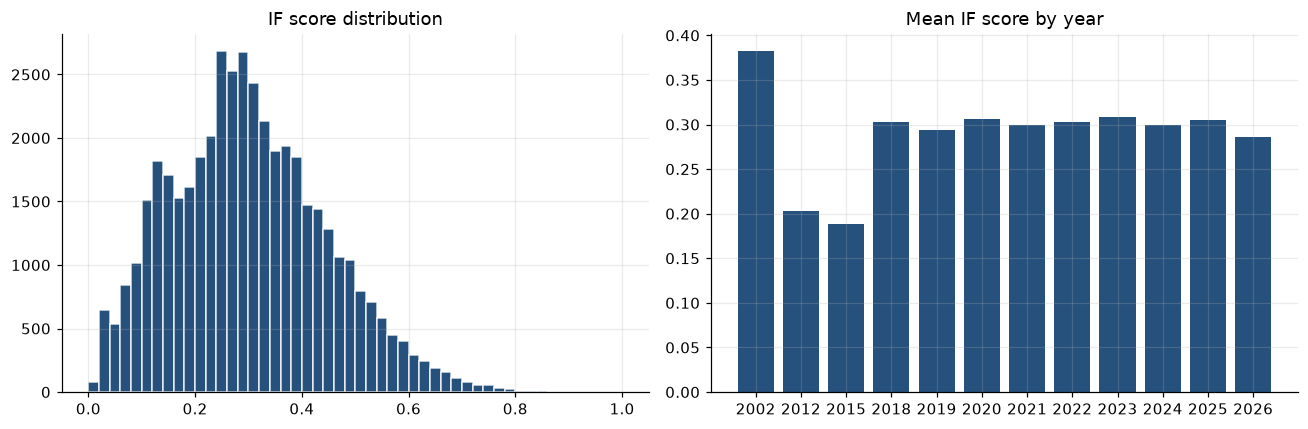

In [30]:
if_features = get_if_feature_columns(asrs)
display(pd.DataFrame({"feature": if_features + ["month_sin", "month_cos"], "role": ["categorical IF feature"] * len(if_features) + ["cyclic seasonality", "cyclic seasonality"]}))
display(asrs["if_score"].describe().to_frame("if_score"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(asrs["if_score"], bins=50, color="#003366", alpha=0.85, edgecolor="white")
axes[0].set_title("IF score distribution")
yearly_if = asrs.groupby(asrs["date"].dt.year)["if_score"].mean()
axes[1].bar(yearly_if.index.astype(str), yearly_if.to_numpy(), color="#003366", alpha=0.85)
axes[1].set_title("Mean IF score by year")
plt.tight_layout()


## 2x2 Quadrant Audit

The RED quadrant means both structured novelty and anomalous category frequency.


<!-- notebook-rationale -->
## How to interpret the quadrants

The quadrant is not a severity label. It is an early-warning prioritization lens. RED means an incident is both structurally novel and part of an anomalous frequency category-month. ORANGE means the category is spiking but the incident itself looks structurally familiar. YELLOW means the incident is novel but not yet frequent. GREEN means neither signal fired.

This design helps an analyst choose the next action. RED incidents deserve immediate pattern review. ORANGE incidents deserve frequency-root-cause review. YELLOW incidents should be watched for recurrence. GREEN incidents can still contain important human-factors risk, which is why Layer 3 exists.


In [31]:
order = ["RED", "ORANGE", "YELLOW", "GREEN"]
counts = asrs["quadrant"].value_counts()
quadrants = pd.DataFrame({"quadrant": order, "incidents": [int(counts.get(q, 0)) for q in order], "pct_of_corpus": [round(counts.get(q, 0) / len(asrs) * 100, 1) for q in order]})
display(quadrants)
assert counts.to_dict() == {"GREEN": 35105, "ORANGE": 6532, "YELLOW": 1920, "RED": 272}


,quadrant,incidents,pct_of_corpus
0,RED,272,0.6
1,ORANGE,6532,14.9
2,YELLOW,1920,4.4
3,GREEN,35105,80.1


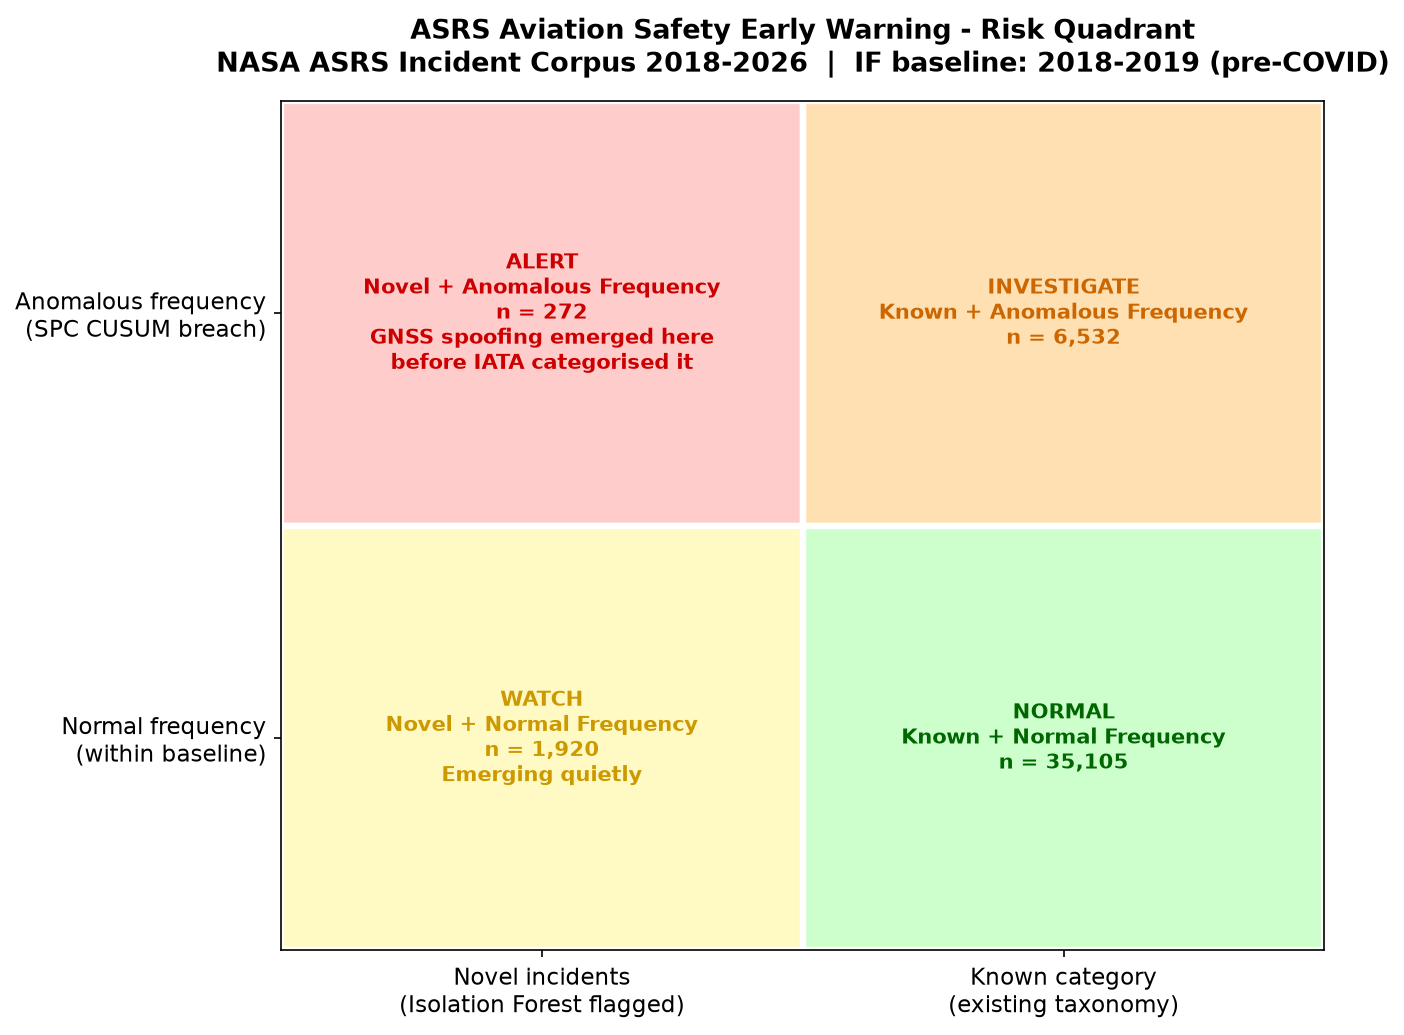

In [32]:
display(Image(filename=str(FIGURES_DIR / "2x2_quadrant.png")))


## GNSS Narrative Signal

GNSS spoofing/jamming is tracked as a separate narrative-derived signal. Some GNSS-related incidents may appear in RED, but the quadrant flag is driven by structured ASRS anomaly-category alarms plus IF novelty, not by the GNSS regex CUSUM itself.


<!-- notebook-rationale -->
## Why GNSS is treated separately from the quadrant

GNSS spoofing and jamming are the headline early-warning story, but the narrative CUSUM is not the direct driver of `spc_flag`. That is deliberate. The quadrant uses structured ASRS anomaly categories and IF novelty, while the GNSS storyline uses narrative pattern detection as an independent signal.

This separation makes the claim more defensible. The project is not saying every GNSS report is RED. It is saying the narrative signal shows a clear uplift and April 2024 CUSUM alarm, while the broader Layer 1 framework prioritizes incidents using structured category alarms plus novelty.


In [33]:
GNSS_REGEX = r"spoof|jamm|gps.{0,25}interfer|gnss.{0,25}interfer|gps.{0,25}denial|gps.{0,25}unreliable|gps.{0,25}degrad|position.{0,25}spoof|gps.{0,25}lost|navigation.{0,25}warn|gps.{0,25}alert"
gnss_mask = asrs["full_narrative"].astype(str).str.lower().str.contains(GNSS_REGEX, regex=True, na=False)
gnss_yearly = asrs.loc[gnss_mask].groupby(asrs.loc[gnss_mask, "date"].dt.year)["ACN"].count()
display(gnss_yearly.rename("GNSS narrative incidents").to_frame())
print(f"GNSS narrative incidents: {gnss_mask.sum():,}")


,GNSS narrative incidents
date,
2018,26
2019,69
2020,42
2021,60
2022,40
2023,75
2024,156
2025,157
2026,11


GNSS narrative incidents: 636


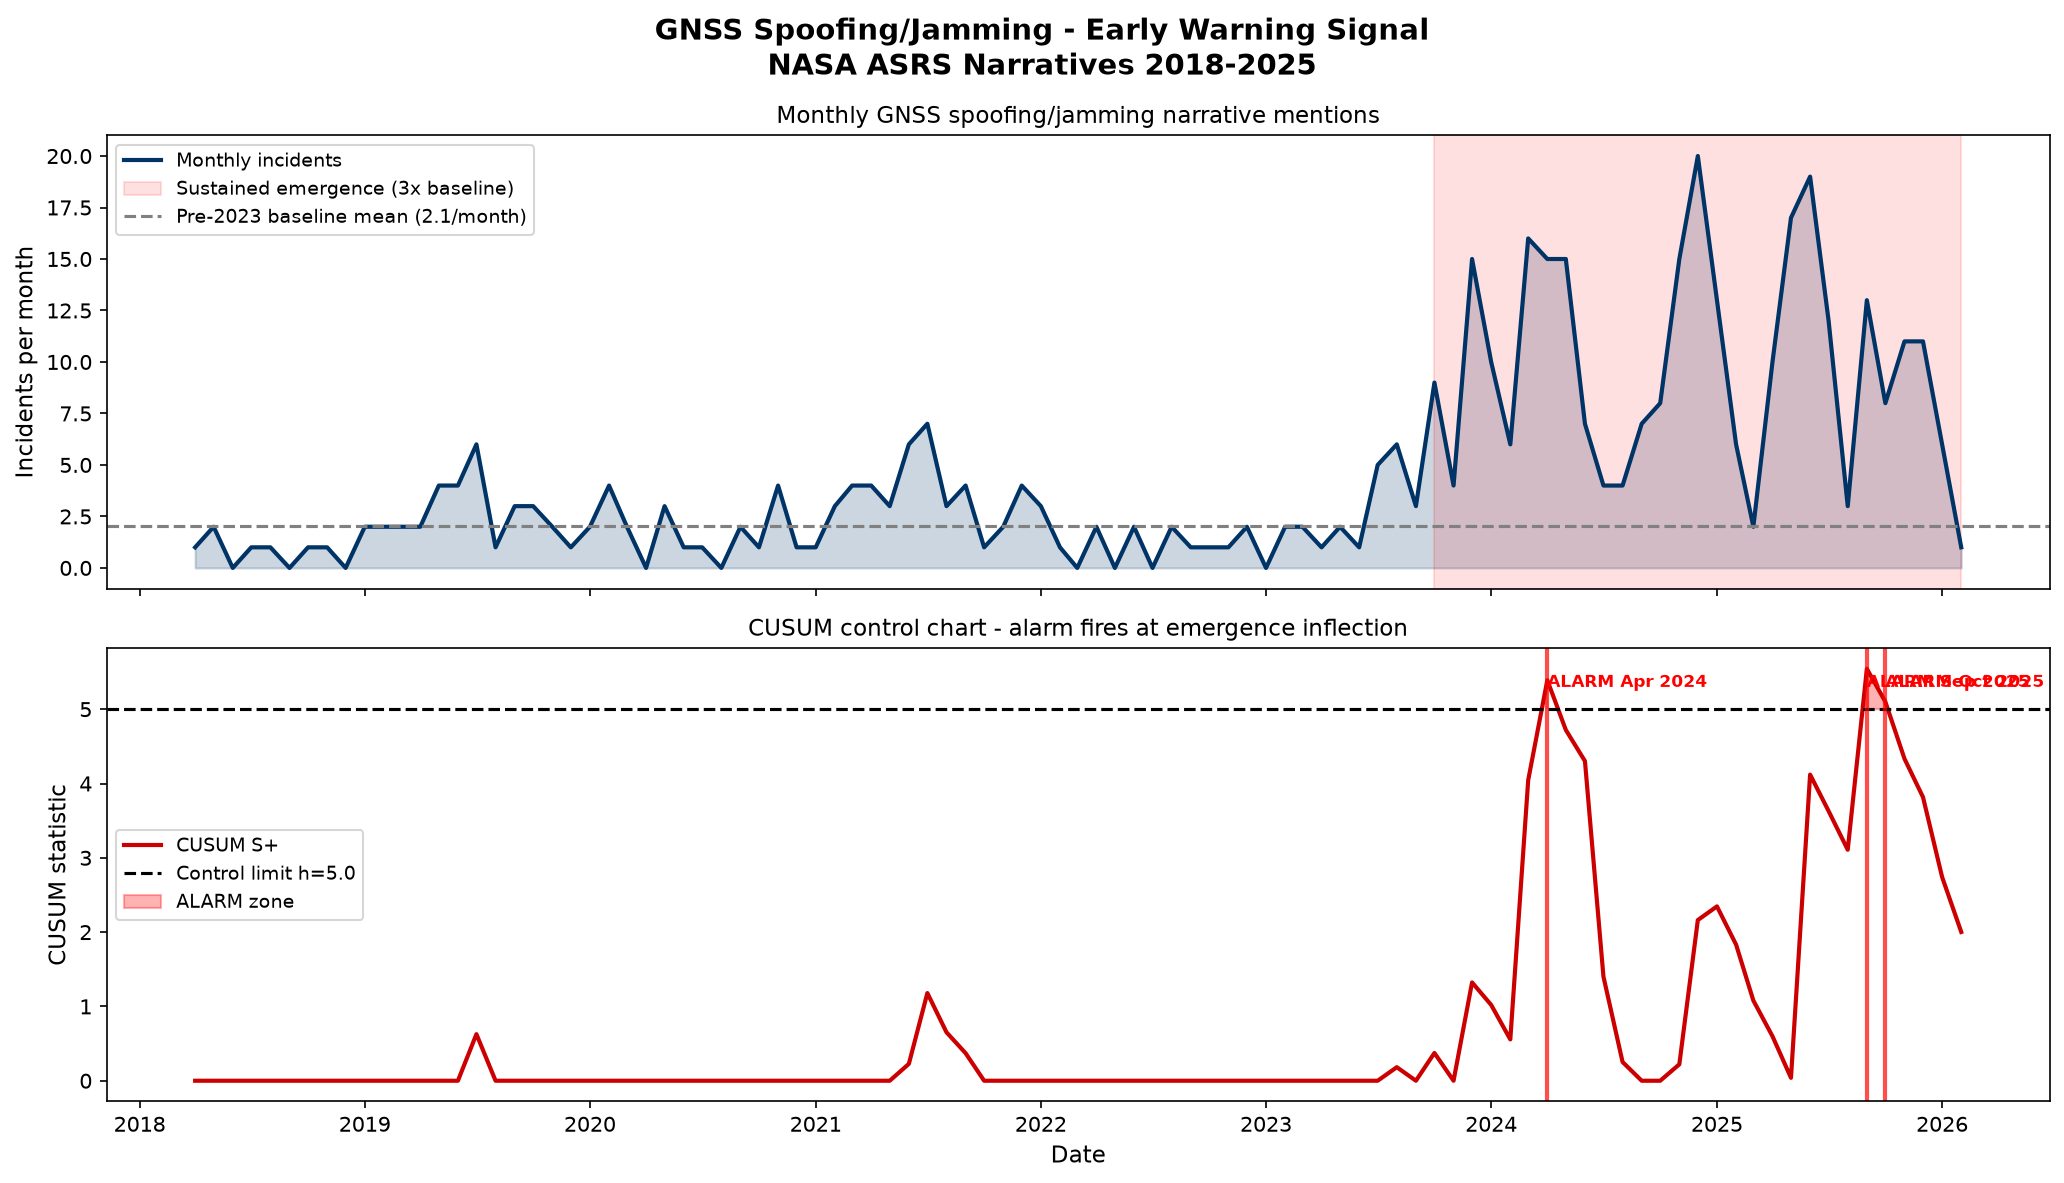

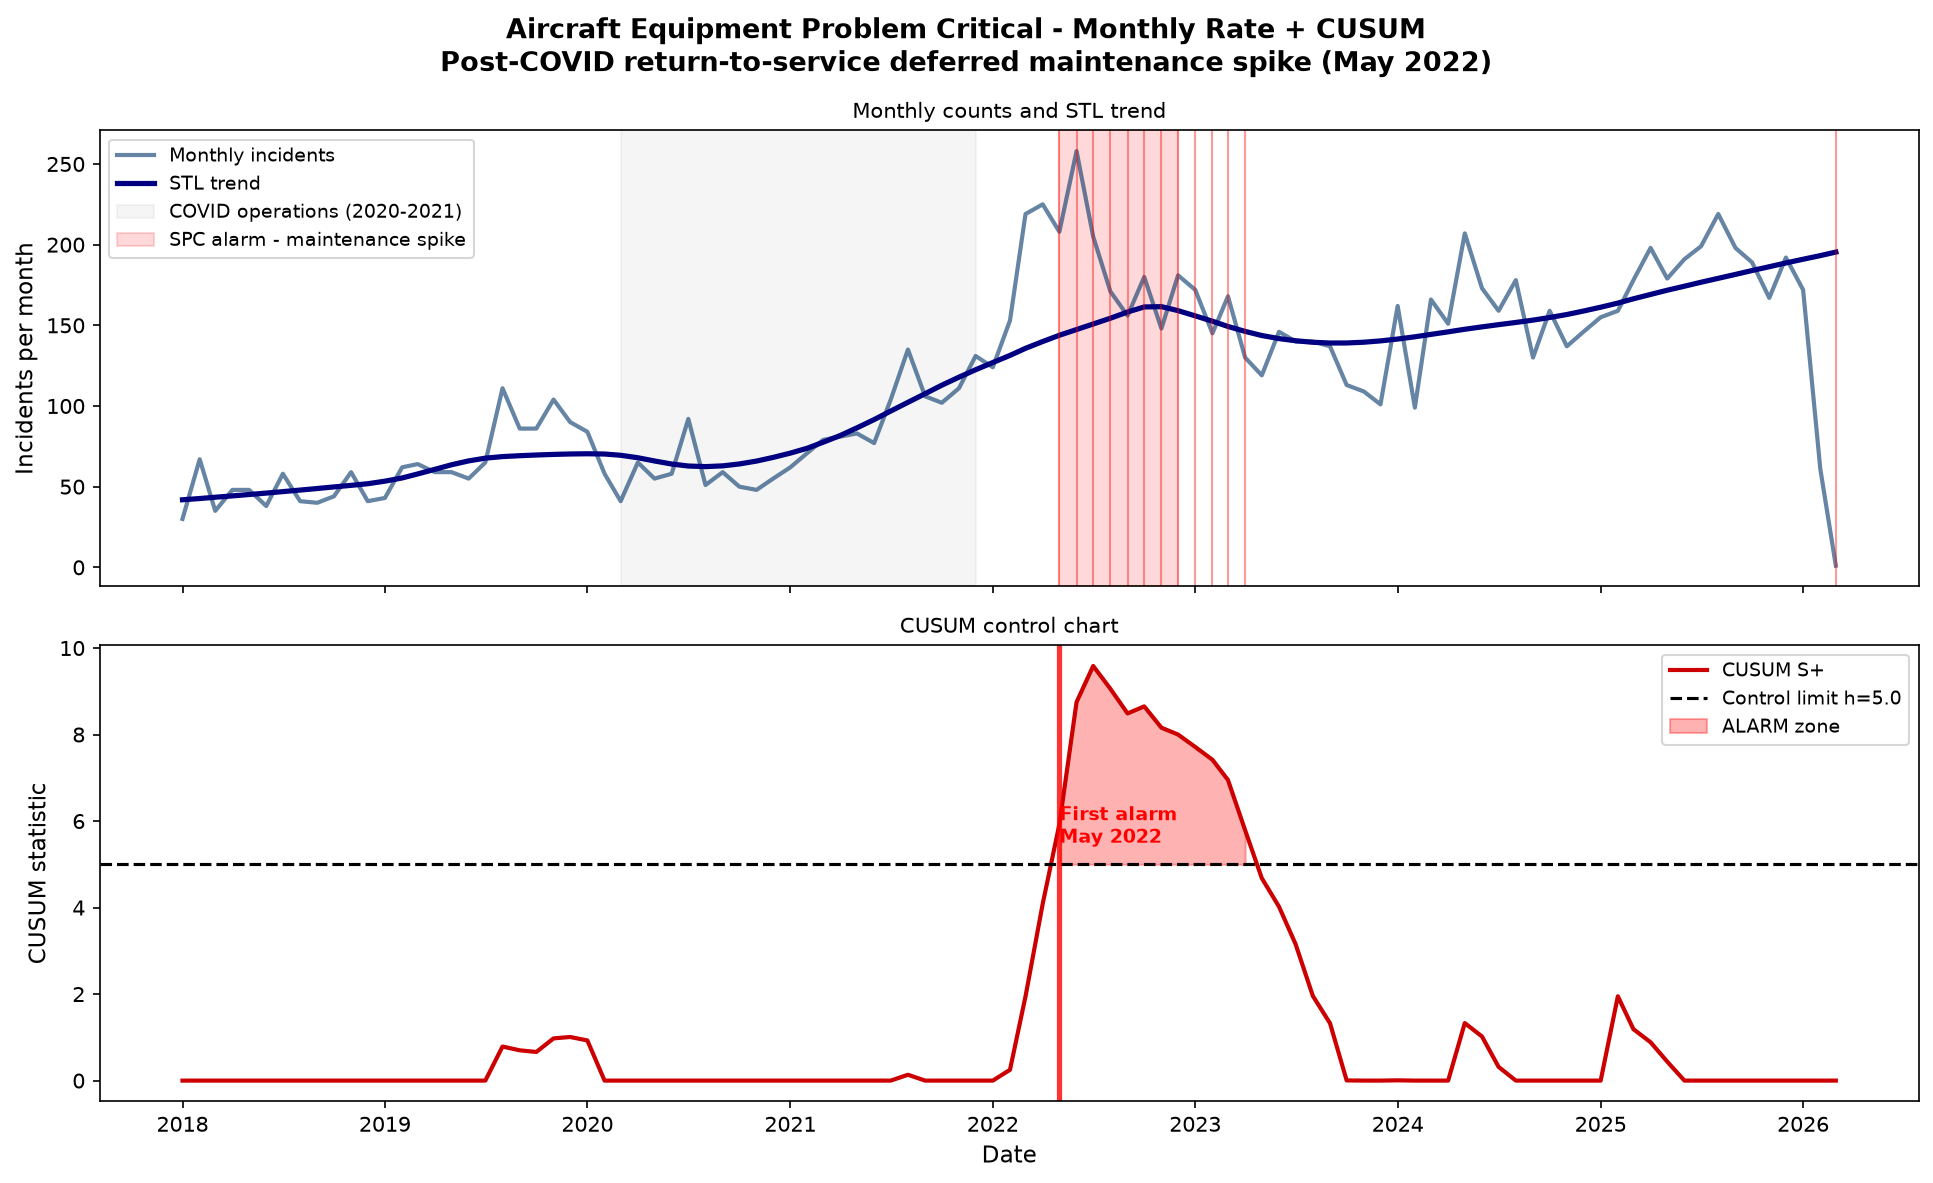

In [34]:
display(Image(filename=str(FIGURES_DIR / "gnss_emergence.png")))
display(Image(filename=str(FIGURES_DIR / "equipment_critical_spc.png")))


## Layer 1 to Layer 2 Handoff

Layer 1 adds `if_score`, `if_flag`, `spc_flag`, `quadrant`, and exact anomaly indicator columns. Layer 2 consumes the same incidents and asks whether narrative semantics independently validate or refine the structured anomaly signals.


<!-- notebook-rationale -->
## Why Layer 2 is needed after Layer 1

Layer 1 uses structured fields and exact categories. That is auditable, but it can miss semantic patterns that are not yet formalized in taxonomy. Layer 2 asks whether the narratives themselves form coherent clusters and whether those clusters independently validate the GNSS/RF interference story.
